### Train Preprocess Pipeline

### 1. Set Kernel Env

In [1]:
# %%bash

# PKGs=$(
#     /opt/conda/envs/python3.9.25_spark_scrach_kernel/bin/pip3 list -v \
#     | grep "/home/$USER/.local/lib/python.*/site-packages" \
#     | awk '{printf "%s==%s ", $1, $2}'
# ) && \
# echo "%pip uninstall -y $PKGs"

In [2]:
# %pip install -e /home/gorelova_i_v/projects/cvm_churn-from-dac_binary-class_churn-dac

In [ ]:
%load_ext autoreload
%load_ext dotenv
%dotenv
%autoreload 2

from IPython.display import display

import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

from datetime import datetime
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path(os.getenv('PROJECT_ROOT_PATH'))

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
import phik

from cvm_model.io import State
import cvm_model.utils as utils
import cvm_model.sql as sql

from cvm_model.train.preprocess import _prepare_dataset, _validate_dataset
from cvm_model.parameters import (
    SAMPLE_SIZE,
    RANDOM_STATE,
    HOLDOUT_SIZE,
    features_for_outliers,
    aud_table,
    fav_omni_features_table,
    preperiod_months,
    target,
    input_suffix,
)

from sklearn.model_selection import train_test_split

### 2. State and Connections

In [4]:
try:
    spark.stop()
except NameError:
    pass

state = State.from_env()
engine = state.credentials.loyalty_gp.sa_engine
s3 = state.credentials.cvm_s3
print('State loaded')

State loaded


### 3. Set Event Timestamp

In [5]:
event_timestamp = datetime(2026, 5, 1)

In [6]:
run_month = pd.Timestamp(event_timestamp.date().replace(day=1).isoformat())

base_month = (run_month - pd.DateOffset(months=2)).date().isoformat()
target_month = (run_month - pd.DateOffset(months=1)).date().isoformat()
feature_date = target_month
base_month_suffix = base_month.replace('-', '_')

aud_table_month = f'{aud_table}_{base_month_suffix}'
fav_omni_features_table_month = f'{fav_omni_features_table}_{base_month_suffix}'

base_month, target_month, feature_date

('2026-03-01', '2026-04-01', '2026-04-01')

### 4. Resolve S3 Input Path

In [7]:
input_prefix = state.settings.preprocess_prefix(event_timestamp) / input_suffix
input_bucket = input_prefix.split('//')[1].split('/')[0]
input_prefix = '/'.join(input_prefix.split('//')[1].split('/')[1:])

train_prefix = f'{input_prefix}/train'
holdout_prefix = f'{input_prefix}/holdout'
utils.remove_s3_prefix(s3, input_bucket, train_prefix)
utils.remove_s3_prefix(s3, input_bucket, holdout_prefix)
assert not utils.list_s3_objects(s3, input_bucket, train_prefix), 'S3 train prefix was not cleaned'
assert not utils.list_s3_objects(s3, input_bucket, holdout_prefix), 'S3 holdout prefix was not cleaned'

input_prefix, input_bucket, train_prefix, holdout_prefix

('ml_platform/churn/cvm_churn-from-dac_binary-class_churn-dac/temporary_1/2026-05-01/input',
 'cvm-current-customer-data')

### 5. Audience Table

Аудиторией являются пользователи, которые имеют статус DAC в `base_month`, определяемый
по `event_timestamp`.


При этом статус DAC определяется актуальной бизнес-логикой:

```SQL
   has_transaction_activity = 1
   and (
       has_mobapp_activity = 1
       or has_pwa_activity = 1
       or vcoff_trn_cnt > 0
       )
```

Для EDA и базового анализа фичей принимается случайная подвыборка из суммарной аудитории DAC в `base_month`.

In [8]:
%%time

full_aud_query = sql.aud_query.format(base_month=base_month)
df = utils.get_df(engine, full_aud_query).fillna(0)

df = df.astype({col: np.int64 for col in {'contact_id'} & set(df.columns)})
assert len(df) > 0, 'No DAC audience contacts were loaded'
assert df['contact_id'].is_unique, 'DAC audience contains duplicate contact_id values'

logging.info(f'Full audience shape: {df.shape}')

INFO:root:Full audience shape: (22592364, 1)


CPU times: user 42.2 s, sys: 4.97 s, total: 47.2 s
Wall time: 54.6 s


### 5. Target Feature

`target_churn_from_dac = 1` - клиент был DAC в базовом месяце и не DAC в следующем.

In [9]:
%%time

df_part = utils.get_df(engine, sql.target_query.format(aud=full_aud_query, target_month=target_month))
df_part = df_part.astype({col: np.int32 for col in {target} & set(df_part.columns)})
assert df_part['contact_id'].is_unique, 'target_query returned duplicate contact_id values'

df = df.merge(df_part, on='contact_id', how='inner')
assert len(df) > 0, 'Dataset is empty after target labeling'

logging.info(f'After target: {df.shape}; target rate = {df[target].mean():.6f}')

INFO:root:After target: (22592364, 2); target rate = 0.145787


CPU times: user 1min 4s, sys: 7.4 s, total: 1min 11s
Wall time: 1min 21s


### 6. Sample of Audience

In [10]:
df, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[target],
    )

df = df.reset_index(drop=True)

logging.info(f'After deterministic sample: {df.shape}; target rate = {df[target].mean():.6f}')

# Upload sampled audience to GP
utils.upload_df(engine, pd.DataFrame(df['contact_id']).astype(np.int64), aud_table_month)
aud_query = f'select distinct contact_id ::bigint as contact_id from {aud_table_month}'

INFO:root:After deterministic sample: (1500000, 2); target rate = 0.145787
INFO:root:Loading cvm_sbx.cvm_churn_from_dac_binary_class_churn_dac_aud_2026_03_01 batch 00000


### 6. Load all Features

In [11]:
%%time

logging.info(f'Load features...')
df = utils.load_features(
    engine=engine,
    df=df,
    aud_query=aud_query,
    date=feature_date,
    fav_omni_features_table=fav_omni_features_table_month,
    preperiod_months=preperiod_months,
)

INFO:root:Load features...


INFO:root:recency: added 4 columns; shape=(1500000, 6)
INFO:root:perf_recency: added 1 columns; shape=(1500000, 7)
INFO:root:Loading cheques features for 12 months
INFO:root:cheques_12m: added 16 columns; shape=(1500000, 23)
INFO:root:Loading cheques_short features for 6 months
INFO:root:cheques_short_6m: added 4 columns; shape=(1500000, 27)
INFO:root:Loading cheques_short features for 3 months
INFO:root:cheques_short_3m: added 4 columns; shape=(1500000, 31)
INFO:root:Loading cheques_short features for 2 months
INFO:root:cheques_short_2m: added 4 columns; shape=(1500000, 35)
INFO:root:Loading cheques_short features for 1 months
INFO:root:cheques_short_1m: added 4 columns; shape=(1500000, 39)
INFO:root:Loading logins features for 12 months
INFO:root:logins_12m: added 2 columns; shape=(1500000, 41)
INFO:root:Loading logins features for 6 months
INFO:root:logins_6m: added 2 columns; shape=(1500000, 43)
INFO:root:Loading logins features for 3 months
INFO:root:logins_3m: added 2 columns; sh

CPU times: user 8min 58s, sys: 49.4 s, total: 9min 47s
Wall time: 1h 50min 48s


In [12]:
df = _prepare_dataset(df)
_validate_dataset(df, 'full_dataset')

### 12. Target Distribution

In [14]:
numeric_features = [f for f in df.columns if pd.api.types.is_numeric_dtype(df[f])]
eda_df = df[numeric_features].copy()

target_counts = df[target].value_counts(dropna=False).sort_index()
target_share = df[target].value_counts(normalize=True, dropna=False).sort_index()
target_report = pd.concat([target_counts.rename('cnt'), target_share.rename('share')], axis=1)

display(target_report)
print('df shape:', df.shape)
print('numeric features:', len(numeric_features))
print('target:', target)

,cnt,share
0,1281320,0.854213
1,218680,0.145787


df shape: (1500000, 144)
numeric features: 141
target: target_churn_from_dac


### 13. Missing, Zero And Basic Stats

In [15]:
eda_report = pd.DataFrame(index=numeric_features)

eda_report['dtype'] = df[numeric_features].dtypes.astype(str)
eda_report['missing_share'] = df[numeric_features].isna().mean()
eda_report['zero_share'] = (df[numeric_features] == 0).mean()
eda_report['nunique'] = df[numeric_features].nunique(dropna=True)
eda_report['mean'] = df[numeric_features].mean(numeric_only=True)
eda_report['std'] = df[numeric_features].std(numeric_only=True)
eda_report['p01'] = df[numeric_features].quantile(0.01, numeric_only=True)
eda_report['p50'] = df[numeric_features].quantile(0.50, numeric_only=True)
eda_report['p99'] = df[numeric_features].quantile(0.99, numeric_only=True)

display(eda_report.sort_values(['missing_share', 'zero_share'], ascending=False))

,dtype,missing_share,zero_share,nunique,mean,std,p01,p50,p99
omni_features_lag_avg_1,float64,0.734259,0.034361,775,4.241005,4.825918,0.000000,2.777780,24.0
omni_features_lag_avg_2,float64,0.618278,0.031101,2274,8.939081,10.071561,0.000000,5.250000,46.0
omni_features_lag_avg_3,float64,0.549360,0.029562,4142,12.013744,13.560905,0.000000,7.200000,66.0
omni_qr_lag_avg_1,float64,0.442693,0.000000,275,5.975985,4.654892,1.000000,4.500000,24.0
omni_features_lag_avg_6,float64,0.416618,0.031684,11952,18.441416,22.473599,0.000000,11.100000,115.0
...,...,...,...,...,...,...,...,...,...
dac_months_last_3,int64,0.000000,0.000000,3,2.626912,0.664384,1.000000,3.000000,3.0
dac_months_last_6,int64,0.000000,0.000000,6,4.923609,1.551720,1.000000,6.000000,6.0
dac_months_last_12,int64,0.000000,0.000000,12,8.845924,3.580009,1.000000,10.000000,12.0
dac_months_per_dac_age_ratio,float64,0.000000,0.000000,780,0.799714,0.235672,0.140000,0.894737,1.0


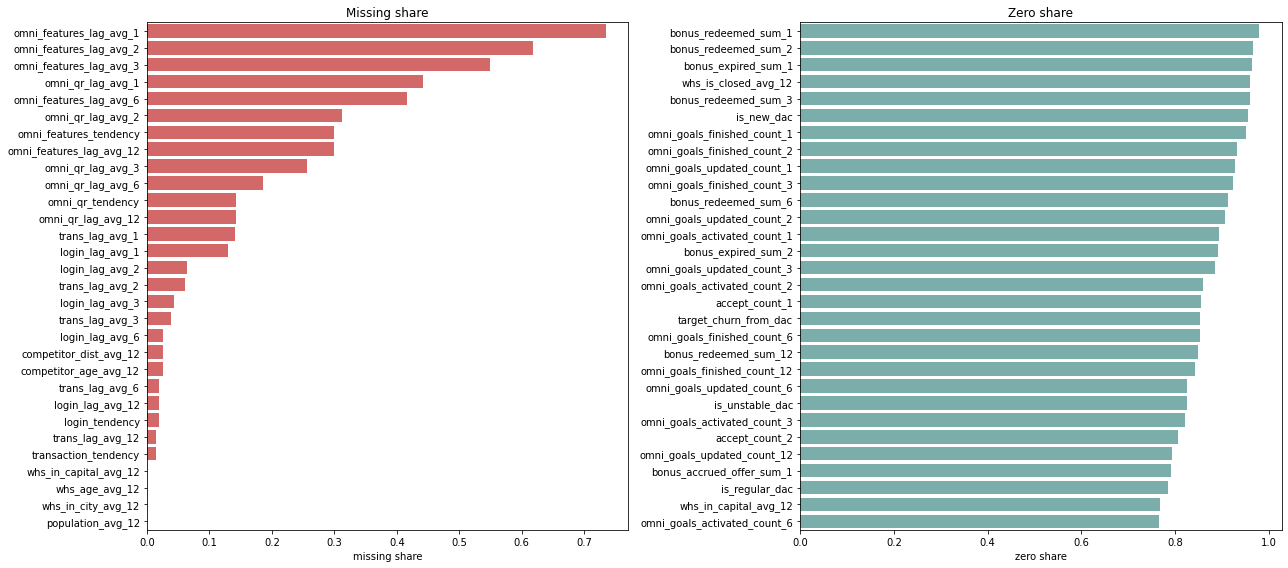

In [16]:
plot_report = eda_report.sort_values('missing_share', ascending=False).head(30).reset_index(names='feature')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(data=plot_report, y='feature', x='missing_share', ax=axes[0], color='#E45756')
axes[0].set_title('Missing share')
axes[0].set_xlabel('missing share')
axes[0].set_ylabel('')

plot_zero = eda_report.sort_values('zero_share', ascending=False).head(30).reset_index(names='feature')
sns.barplot(data=plot_zero, y='feature', x='zero_share', ax=axes[1], color='#72B7B2')
axes[1].set_title('Zero share')
axes[1].set_xlabel('zero share')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 14. DAC Segments

In [ ]:
# DAC segmenation by sum of the DAC months over last 12 months

segment_report = (
    df.groupby('dac_segment_12m', dropna=False)
    .agg(
        cnt=(target, 'size'),
        target_rate=(target, 'mean'),
        dac_months_last_12_mean=('dac_months_last_12', 'mean'),
    )
    .sort_values('target_rate', ascending=False)
)

In [18]:
display(df.groupby('segment')[target].agg(['count', 'mean']).sort_values('mean', ascending=False))

,count,mean
segment,,
new_1m,64865,0.422246
unstable_2_5m,262340,0.307658
regular_6_9m,323103,0.206909
stable_10_12m,849692,0.051462


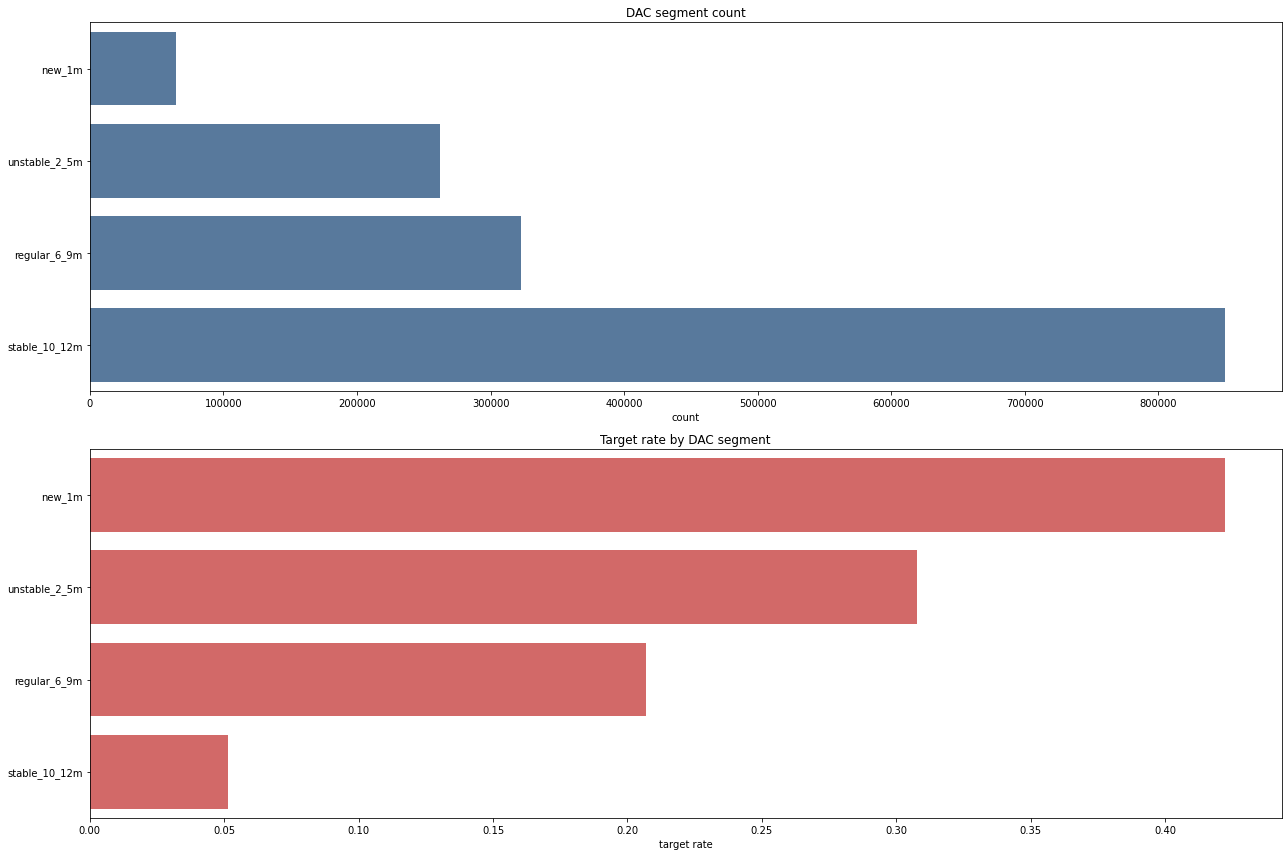

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

sns.countplot(data=df, y='dac_segment_12m', order=segment_report.index, ax=axes[0], color='#4C78A8')
axes[0].set_title('DAC segment count')
axes[0].set_xlabel('count')
axes[0].set_ylabel('')

sns.barplot(data=segment_report.reset_index(), y='dac_segment_12m', x='target_rate', ax=axes[1], color='#E45756')
axes[1].set_title('Target rate by DAC segment')
axes[1].set_xlabel('target rate')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()

### 15. Correlation Matrix (Phik & Spearman)

In [20]:
phik_sample_n = min(len(eda_df), 10_000)
phik_df = eda_df.sample(phik_sample_n, random_state=42) if len(eda_df) > phik_sample_n else eda_df.copy()

phik_cols = [c for c in phik_df.columns if phik_df[c].notna().sum() > 0 and phik_df[c].nunique(dropna=True) > 1]
phik_df = phik_df[phik_cols]
interval_cols = [c for c in phik_cols if c != target]

phik_matrix = phik_df.phik_matrix(interval_cols=interval_cols)

phik_target = (
    phik_matrix[target]
    .drop(target, errors='ignore')
    .sort_values(ascending=False)
)

In [21]:
display(phik_target.to_frame('phik_with_target').head(15))

,phik_with_target
dac_months_last_6,0.532878
is_stable_dac,0.473667
dac_months_last_12,0.451324
dac_share_last_12,0.451324
login_lag_avg_3,0.398204
trans_lag_avg_6,0.372786
omni_qr_days_count_2,0.353268
omni_qr_days_count_3,0.350564
omni_qr_days_count_12,0.346015
login_lag_avg_2,0.344851


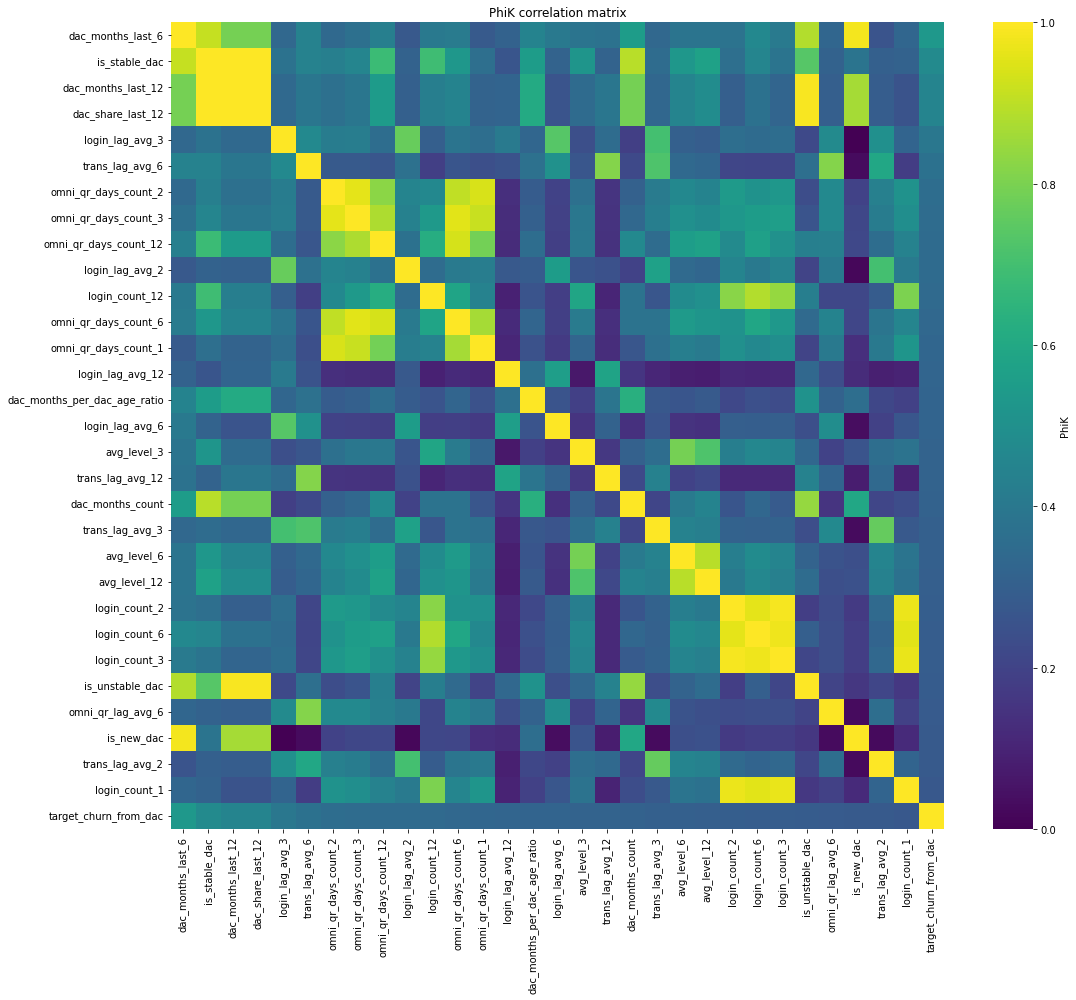

In [22]:
top_phik_features = phik_target.head(30).index.tolist()
heatmap_cols = top_phik_features + [target]

plt.figure(figsize=(16, 14))
sns.heatmap(
    phik_matrix.loc[heatmap_cols, heatmap_cols],
    cmap='viridis',
    vmin=0,
    vmax=1,
    square=False,
    cbar_kws={'label': 'PhiK'},
)
plt.title('PhiK correlation matrix')
plt.tight_layout()
plt.show()

In [23]:
pearson_target = (
    eda_df.corr(method='pearson', numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
spearman_target = (
    eda_df.corr(method='spearman', numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_target_report = pd.concat(
    [pearson_target.rename('pearson'), spearman_target.rename('spearman'), phik_target.rename('phik')],
    axis=1,
).sort_values('phik', ascending=False)

In [24]:
display(corr_target_report.head(15))

,pearson,spearman,phik
dac_months_last_6,-0.381132,-0.377676,0.532878
is_stable_dac,-0.305530,-0.305530,0.473667
dac_share_last_12,-0.343573,-0.342192,0.451324
dac_months_last_12,-0.343573,-0.342192,0.451324
login_lag_avg_3,0.284747,0.276354,0.398204
trans_lag_avg_6,0.291659,0.274486,0.372786
omni_qr_days_count_2,-0.246289,-0.310479,0.353268
omni_qr_days_count_3,-0.250228,-0.322551,0.350564
omni_qr_days_count_12,-0.248245,-0.332125,0.346015
login_lag_avg_2,0.242716,0.228784,0.344851


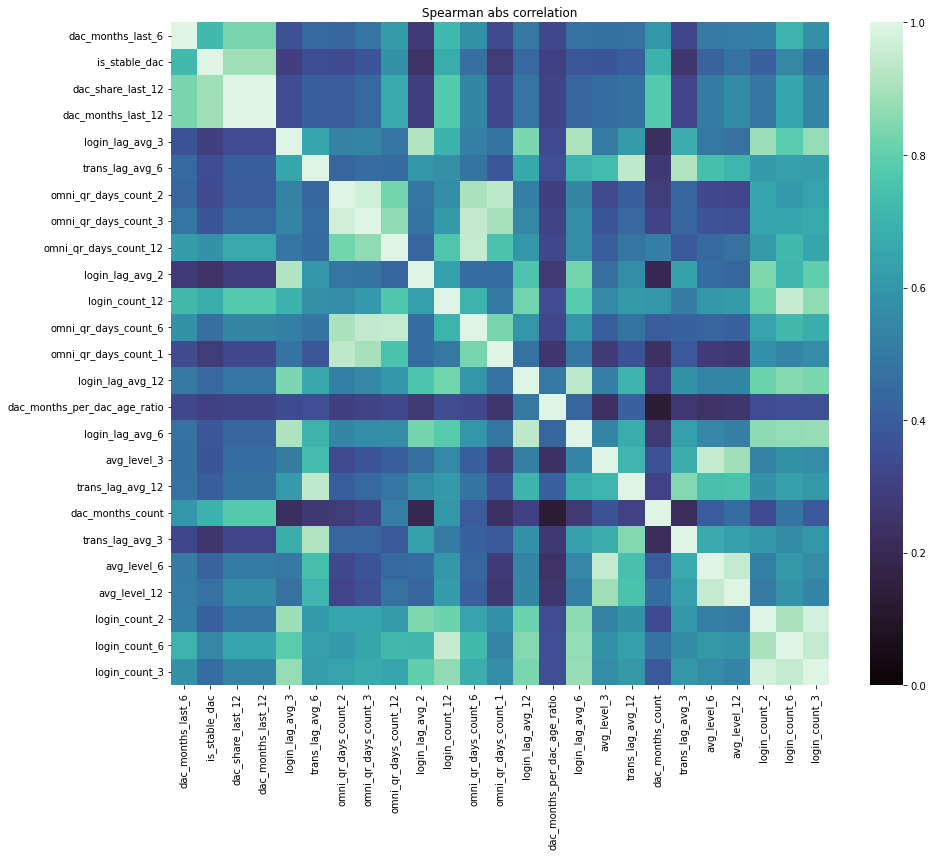

In [25]:
top_corr_features = corr_target_report.head(25).index.tolist()
corr_for_heatmap = eda_df[top_corr_features].corr(method='spearman', numeric_only=True).abs()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_for_heatmap, cmap='mako', vmin=0, vmax=1)
plt.title('Spearman abs correlation')
plt.tight_layout()
plt.show()

upper = corr_for_heatmap.where(np.triu(np.ones(corr_for_heatmap.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'spearman_abs_corr'})
    .sort_values('spearman_abs_corr', ascending=False)
)

In [26]:
display(high_corr_pairs[high_corr_pairs['spearman_abs_corr'] >= 0.80].head(15))

,feature_1,feature_2,spearman_abs_corr
47,dac_share_last_12,dac_months_last_12,1.000000
298,login_count_2,login_count_3,0.974696
129,omni_qr_days_count_2,omni_qr_days_count_3,0.971391
207,login_count_12,login_count_6,0.949658
290,avg_level_6,avg_level_12,0.947871
299,login_count_6,login_count_3,0.947650
267,avg_level_3,avg_level_6,0.947293
166,omni_qr_days_count_12,omni_qr_days_count_6,0.946121
150,omni_qr_days_count_3,omni_qr_days_count_6,0.944635
121,trans_lag_avg_6,trans_lag_avg_12,0.941391


### 16. Outliers

In [27]:
%%time

df['outlier'] = 0
for feature in features_for_outliers:
    if feature in df.columns and df[feature].notna().sum() > 0:
        df.loc[df[feature] > np.nanquantile(df[feature], 0.999), 'outlier'] = 1

outlier_share = df['outlier'].mean()

assert outlier_share <= 0.01, 'More than 1% of the audience was removed as outliers'

df = df[df['outlier'] == 0].drop(columns=['outlier']).reset_index(drop=True)
_validate_dataset(df, 'full_dataset_without_outliers')

logging.info(f'Final dataset shape: {df.shape}; target rate = {df[target].mean():.6f}')

INFO:root:Final dataset shape: (1495265, 144); target rate = 0.146083


CPU times: user 1.61 s, sys: 397 ms, total: 2.01 s
Wall time: 2.01 s


### 17. Feature Selection

In [28]:
drop_manual = {'contact_id', target, 'is_dac_next_month', 'outlier', 'dac_share_last_12'}

available_features = [f for f in df.columns if f not in drop_manual]

feature_rank = corr_target_report.copy()
feature_rank['score_abs'] = feature_rank[['pearson', 'spearman', 'phik']].abs().max(axis=1)
feature_rank = feature_rank.sort_values('score_abs', ascending=False)

feature_quality = pd.DataFrame(index=available_features)
feature_quality['missing_share'] = df[available_features].isna().mean()
feature_quality['nunique'] = df[available_features].nunique(dropna=True)

feature_selection_report = (feature_rank.join(feature_quality, how='left').sort_values('score_abs', ascending=False))

selected_features = feature_selection_report[
(feature_selection_report['missing_share'] < 0.80)
    & (feature_selection_report['nunique'] > 1)
].index.tolist()

In [29]:
TOP_N = 100

selected_features = selected_features[:TOP_N]

print('Available features:', len(available_features))
print('Selected features:', len(selected_features))

Available features: 141
Selected features: 100


### 18. Split Dataset on Train and Holdout parts

In [30]:
df, holdout_df = train_test_split(
    df,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[target],
)

df = df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

overlap = set(df['contact_id']) & set(holdout_df['contact_id'])
assert len(overlap) == 0, 'Train and holdout contact_id overlap'

_validate_dataset(df, 'train')
_validate_dataset(holdout_df, 'holdout')

logging.info(f'Train shape: {df.shape}; target rate = {df[target].mean():.6f}')
logging.info(f'Holdout shape: {holdout_df.shape}; target rate = {holdout_df[target].mean():.6f}')

INFO:root:Train shape: (1196212, 144); target rate = 0.146083
INFO:root:Holdout shape: (299053, 144); target rate = 0.146084


### 19. Save Dataset

In [31]:
%%time

utils.save_df_to_s3(df, s3, input_bucket, f'{input_prefix}/train')
utils.save_df_to_s3(holdout_df, s3, input_bucket, f'{input_prefix}/holdout')


logging.info('Saved to S3')

INFO:root:Saved to S3


CPU times: user 13.6 s, sys: 717 ms, total: 14.3 s
Wall time: 30.4 s


In [32]:
for table in [aud_table_month, fav_omni_features_table]:
    try:
        utils.execute_query(engine, f'drop table if exists {table}')
    except Exception:
        logging.exception(f'Failed to drop temporary table {table}')

Path('df_cache.parquet').unlink(missing_ok=True)